In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

In [5]:
# 1. Data Preparation - Loading the csv file
df = pd.read_csv('../data/q2_customers.csv')
print(df.head())

   age  annual_spend  visits_per_month  basket_size  days_since_last_visit  \
0   30         43075                 9         2080                     45   
1   19         14496                11          454                      8   
2   43         57632                 6         2144                     16   
3   30         15629                10          801                      0   
4   19         14901                16          396                     17   

   num_categories_purchased  
0                         6  
1                         3  
2                         4  
3                         2  
4                         1  


In [6]:
features = ["age", "annual_spend", "visits_per_month", "basket_size", "days_since_last_visit", "num_categories_purchased"]
X = df[features].values

In [7]:
# 1. Data preparation - Scaling Features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

K-Means uses Euclidean Distance, which a distance based algorithm. Some features of the dataset like `annual_spend` and `visits_per_month` have different numerical ranges, which would make it hard to train a model. Scaling ensures every feature contributes equally to the "distance" between customers.

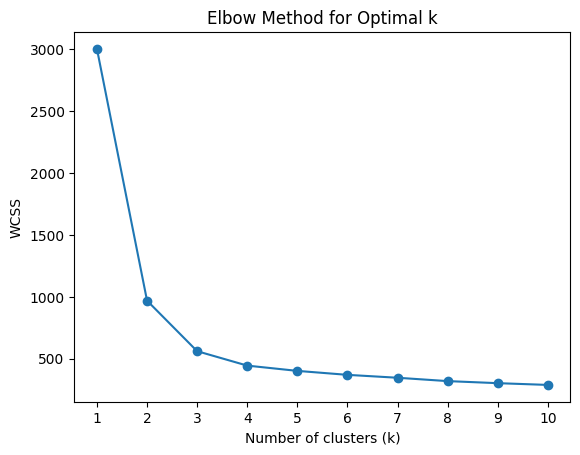

In [9]:
# 2. Choosing K — Elbow Method
inertias = []
K_range = range(1, 11)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)

plt.figure()
plt.plot(K_range, inertias, marker='o')
plt.xticks(K_range)
plt.xlabel("Number of clusters (k)")
plt.ylabel("WCSS")
plt.title("Elbow Method for Optimal k")
plt.show()

The optimal K is chosen where the rate of decrease in WCSS (Within Cluster Sum of Squares) slows down significantly. In this case, WCSS slows down at around 3 clusters. So, the optimal K value is chosen as 3.

In [11]:
# 3. K-Means Clustering
k_opt = 3 
kmeans = KMeans(n_clusters=k_opt, random_state=42, n_init=10)
df["cluster"] = kmeans.fit_predict(X_scaled)

print(df[["cluster"] + features].head(10))

centers_original = scaler.inverse_transform(kmeans.cluster_centers_)
centers_df = pd.DataFrame(centers_original, columns=features)
centers_df["cluster"] = range(k_opt)
print(centers_df)

   cluster  age  annual_spend  visits_per_month  basket_size  \
0        2   30         43075                 9         2080   
1        0   19         14496                11          454   
2        2   43         57632                 6         2144   
3        0   30         15629                10          801   
4        0   19         14901                16          396   
5        2   46         54692                10         2593   
6        2   35         26579                 8         2694   
7        0   22          9158                14          591   
8        0   18         20782                10          571   
9        2   40         29838                11          930   

   days_since_last_visit  num_categories_purchased  
0                     45                         6  
1                      8                         3  
2                     16                         4  
3                      0                         2  
4                     17      

Cluster 0, around the age group 24 years, visit the store quite frequently compared to other age groups, at about 14.34 (~15) times per month. But the basket size and annual spend is pretty less as compared to the rest of the age gorups. This could suggest that this age group focuses on buying only necessities and wants to save money. 

Cluster 1, age group around 56 years, spend a lot annually, 89,413 rupees. They visit the store around twice a month. The least out of all clusters. But their basket size is huge, which could mean that they buy things in bulk. However, the days since last visit is the highest among the others. This could lead to customer disengagement.

Cluster 2, age group around 40 years, spends around 43,341 rupees annually. They visit around 8 - 9 times a month, that could be twice a week for groceries and such, and their basket size sits in between the other groups basket size. 

In [12]:
# 4. Dimensionality Reduction with PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

print("Explained variance ratio:", pca.explained_variance_ratio_)

loadings = pd.DataFrame(
    pca.components_,
    columns=features,
    index=["PC1", "PC2"]
)
print(loadings)

Explained variance ratio: [0.83560354 0.05568764]
          age  annual_spend  visits_per_month  basket_size  \
PC1  0.411569       0.42154         -0.410399     0.412012   
PC2 -0.259432      -0.03327          0.208318    -0.195402   

     days_since_last_visit  num_categories_purchased  
PC1               0.378582                  0.414017  
PC2               0.911194                 -0.140479  


The Variance Ratio tells that, PC1 explains 83.5% of the variance, and PC2 explains about 5.6% of the variance.

In PC1, almost all features have high positive loadings, except for visits_per_month, which is negative (-0.41). Customers with a high PC1 score have higher age, spend, basket size, and days since last visit, but fewer monthly visits. 

In PC2, days_since_last_visit has the highest number (0.91). A high PC2 score says that customers aren't visiting the store as frequently. 

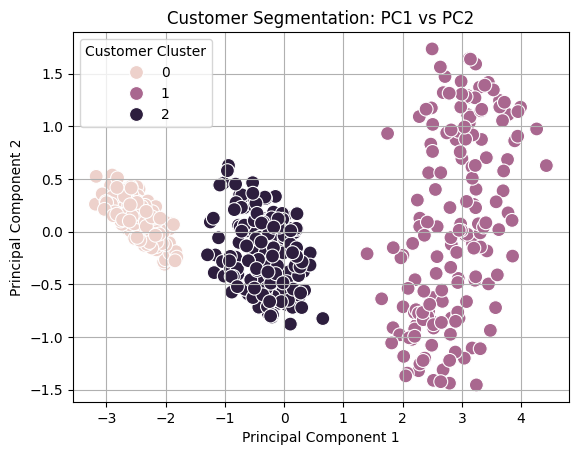

In [ ]:
# 5. Cluster Visualisation
df["PC1"] = X_pca[:, 0]
df["PC2"] = X_pca[:, 1]

plt.figure()
sns.scatterplot(
    data=df,
    x="PC1",
    y="PC2",
    hue="cluster",
    s=100
)
plt.title("Customer Segmentation: PC1 vs PC2")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Customer Cluster")
plt.grid(True)
plt.show()